In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Load the data (put diabetes.csv in the same folder as your notebook)
df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

print("\n--- Info (types and non-null counts) ---")
df.info()

print("\n--- Statistical summary ---")
display(df.describe().T)

print("\n--- Missing values (NaN) ---")
print(df.isnull().sum())

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

--- Info (types and non-null counts) ---
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

--- Statistical summary ---


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00



--- Missing values (NaN) ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,zero_count,zero_percent
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43



Missing values after conversion:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


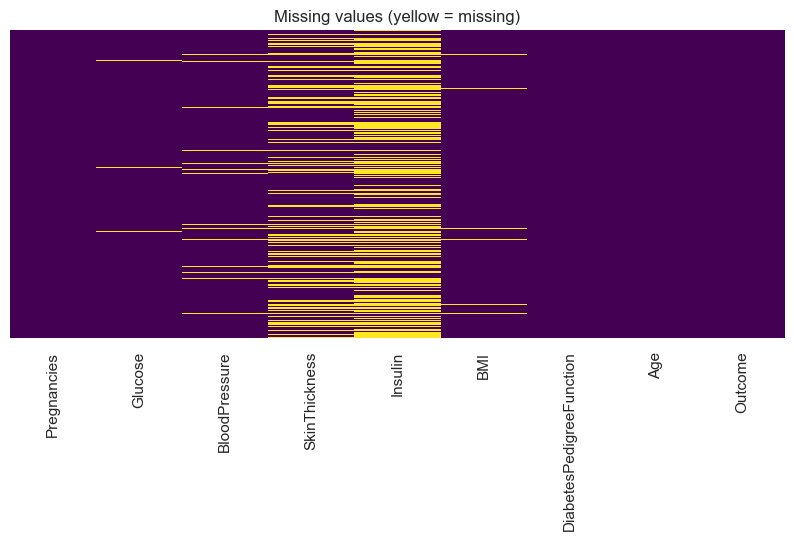

In [3]:
# Columns where 0 is impossible
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 1. Count the hidden zeros
zero_report = pd.DataFrame({
    "zero_count": (df[zero_cols] == 0).sum(),
    "zero_percent": ((df[zero_cols] == 0).mean() * 100).round(2)
})
display(zero_report)

# 2. Replace those zeros with NaN
df[zero_cols] = df[zero_cols].replace(0, np.nan)

# 3. Check the real missing values now
print("\nMissing values after conversion:")
print(df.isnull().sum())

# 4. Visualize where the missing values are
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing values (yellow = missing)")
plt.show()

In [4]:
# 1. Missing summary
miss = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
}).query("missing_count > 0").sort_values("missing_count", ascending=False)
display(miss)

# 2. Does "being missing" relate to the outcome?
for col in miss.index:
    rate = df.groupby(df[col].isnull())["Outcome"].mean().round(3)
    print(f"{col}: diabetes rate when recorded = {rate[False]}, when missing = {rate[True]}")

# 3. How many rows have several missing values?
print("\nMissing values per row:")
print(df.isnull().sum(axis=1).value_counts().sort_index())

# 4. Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

,missing_count,missing_percent
Insulin,374,48.70
SkinThickness,227,29.56
BloodPressure,35,4.56
BMI,11,1.43
Glucose,5,0.65


Insulin: diabetes rate when recorded = 0.33, when missing = 0.369
SkinThickness: diabetes rate when recorded = 0.333, when missing = 0.388
BloodPressure: diabetes rate when recorded = 0.344, when missing = 0.457
BMI: diabetes rate when recorded = 0.351, when missing = 0.182
Glucose: diabetes rate when recorded = 0.349, when missing = 0.4

Missing values per row:
0    392
1    142
2    199
3     28
4      7
Name: count, dtype: int64

Duplicate rows: 0


,count,percent
Outcome,,
0,500,65.1
1,268,34.9


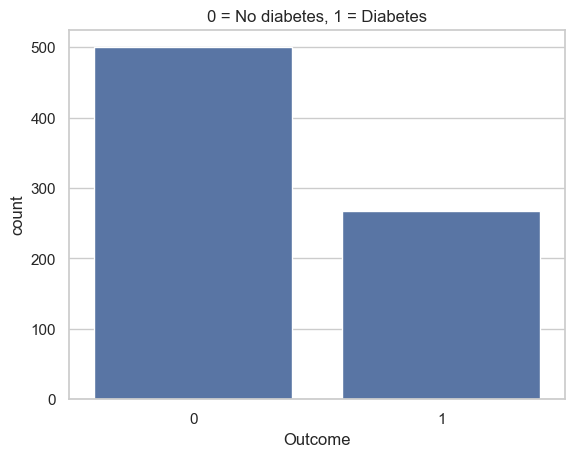

In [5]:
counts = df["Outcome"].value_counts()
percent = (df["Outcome"].value_counts(normalize=True) * 100).round(2)
display(pd.DataFrame({"count": counts, "percent": percent}))

sns.countplot(x="Outcome", data=df)
plt.title("0 = No diabetes, 1 = Diabetes")
plt.show()

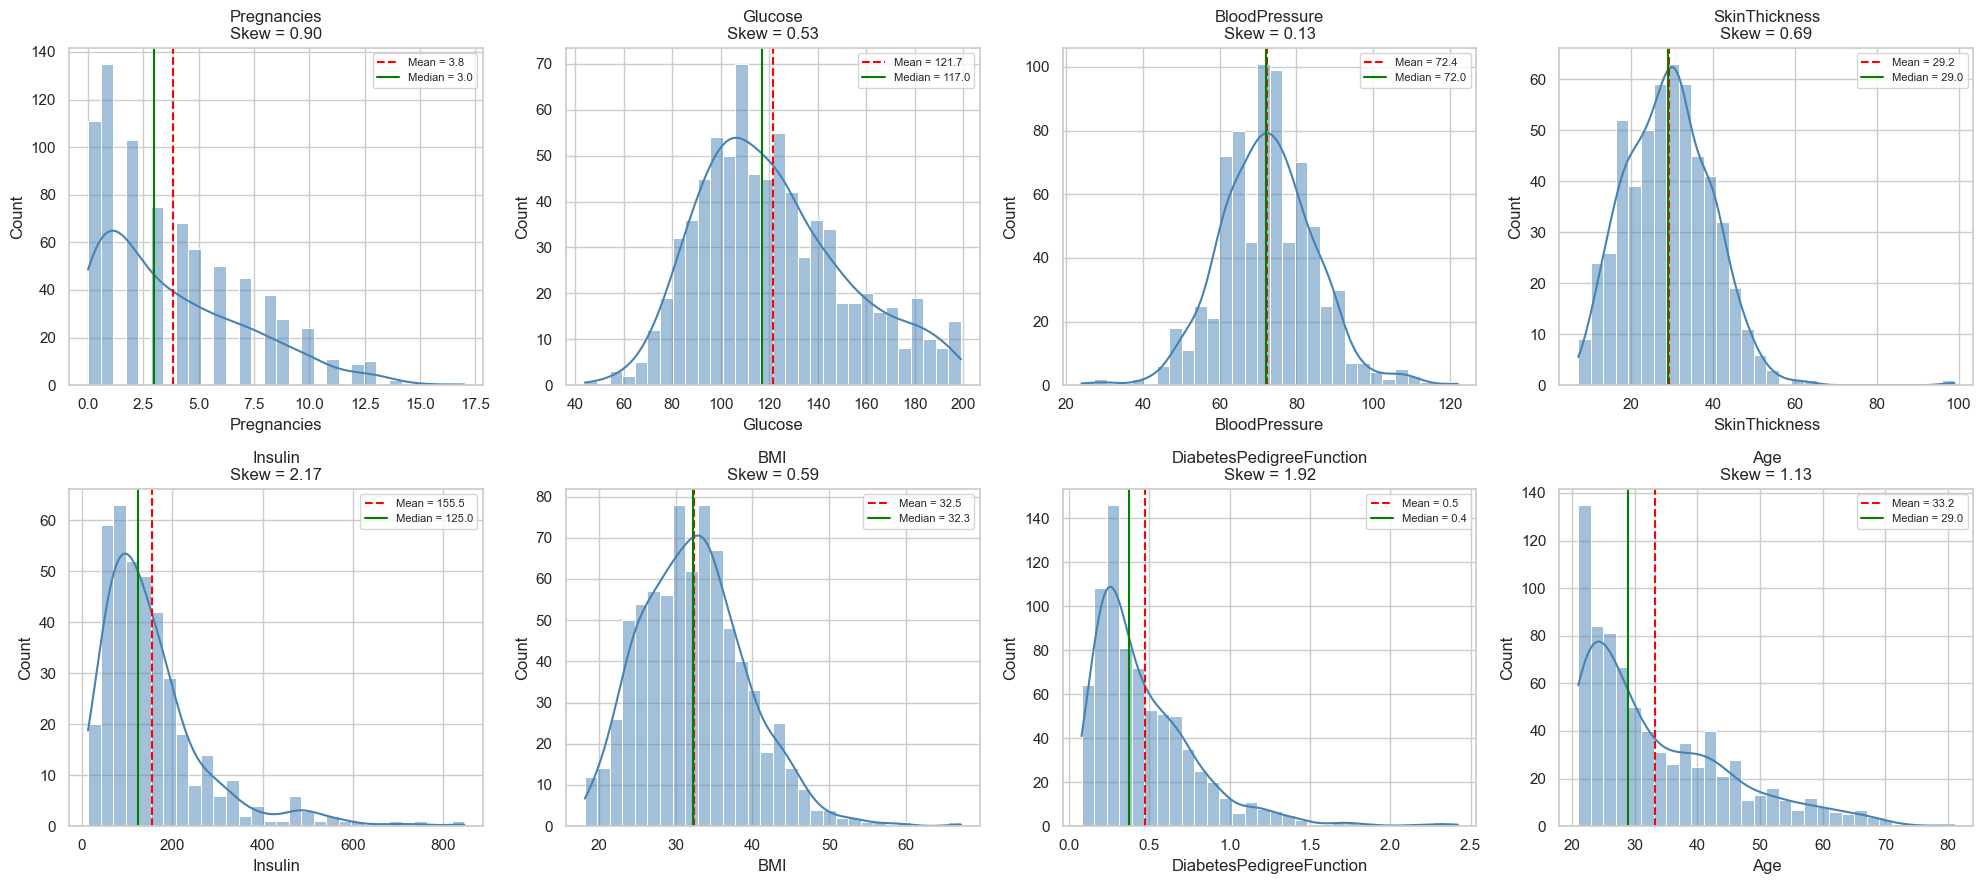

In [6]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.histplot(df[col].dropna(), kde=True, bins=30, ax=ax, color="steelblue")
    ax.axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean = {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="green", linestyle="-", label=f"Median = {df[col].median():.1f}")
    ax.set_title(f"{col}\nSkew = {df[col].skew():.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Pregnancies (skew 0.90): most patients have 0 to 3 pregnancies, with a long tail up to about 17. Mean 3.8 is above median 3.0, so it is moderately right-skewed.
Glucose (skew 0.53): roughly bell-shaped, centered around 110 to 120, with a small tail toward high values. Mean 121.7 and median 117 are close, so it is fairly balanced.
BloodPressure (skew 0.13): almost a perfect bell curve, centered at 72. Mean and median are almost identical (72.4 vs 72.0), so it is the most symmetric feature.
SkinThickness (skew 0.69): mostly bell-shaped around 29, but there is one lone bar near 100. That is an extreme outlier and probably an error.
Insulin (skew 2.17): the most lopsided feature. Most values sit between 50 and 250, but the tail runs out to about 850. Mean 155.5 is far above median 125.
BMI (skew 0.59): roughly bell-shaped around 32, with one stray value near 67. Mean and median are almost the same (32.5 vs 32.3).
DiabetesPedigreeFunction (skew 1.92): strongly right-skewed. Most values are below 0.6, with a long thin tail up to about 2.4. Mean 0.5 is above median 0.4.
Age (skew 1.13): many young patients (the peak is in the early 20s) and fewer older ones, with a tail to 80. Mean 33.2 is above median 29.

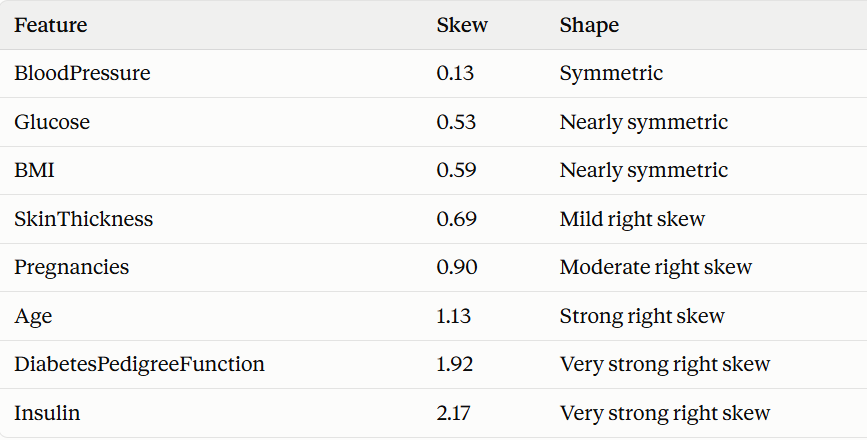

In [7]:
skew_table = df[features].skew().sort_values(ascending=False).round(2).to_frame("skewness")
display(skew_table)

,skewness
Insulin,2.17
DiabetesPedigreeFunction,1.92
Age,1.13
Pregnancies,0.90
SkinThickness,0.69
BMI,0.59
Glucose,0.53
BloodPressure,0.13


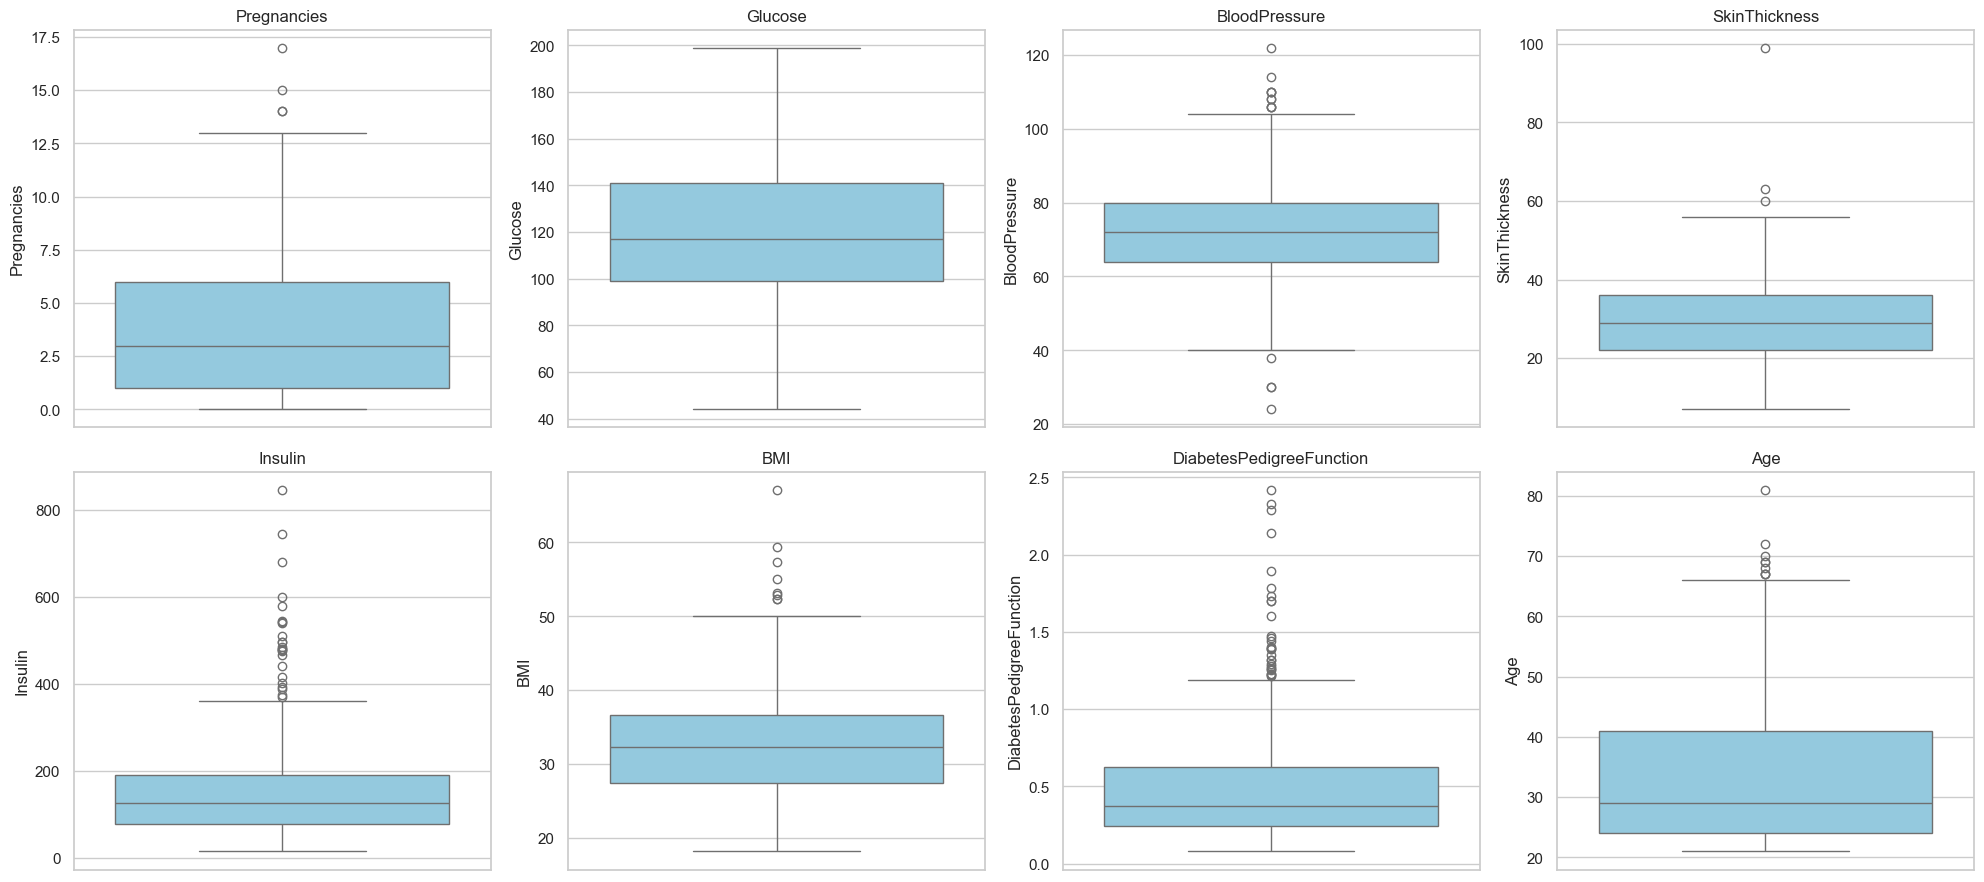

In [8]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [11]:
rows = []
for col in features:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_low = (s < lower).sum()
    n_high = (s > upper).sum()
    rows.append({
        "feature": col,
        "min": s.min(), "max": s.max(),
        "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
        "below": n_low, "above": n_high,
        "outlier_%": round((n_low + n_high) / len(s) * 100, 2),
    })

outlier_report = pd.DataFrame(rows).set_index("feature")
display(outlier_report)

,min,max,lower_bound,upper_bound,below,above,outlier_%
feature,,,,,,,
Pregnancies,0.000,17.00,-6.50,13.50,0,4,0.52
Glucose,44.000,199.00,36.00,204.00,0,0,0.00
BloodPressure,24.000,122.00,40.00,104.00,4,10,1.91
SkinThickness,7.000,99.00,1.00,57.00,0,3,0.55
Insulin,14.000,846.00,-94.38,360.62,0,24,6.09
BMI,18.200,67.10,13.85,50.25,0,8,1.06
DiabetesPedigreeFunction,0.078,2.42,-0.33,1.20,0,29,3.78
Age,21.000,81.00,-1.50,66.50,0,9,1.17


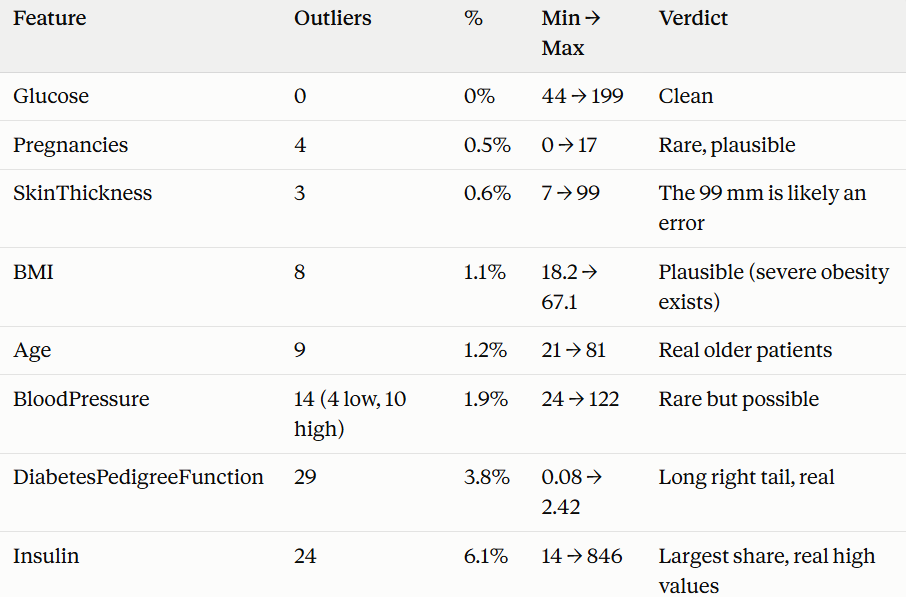

In [12]:
print("Highest SkinThickness:")
display(df.nlargest(3, "SkinThickness"))

print("Highest BMI:")
display(df.nlargest(3, "BMI"))

print("Highest Insulin:")
display(df.nlargest(3, "Insulin"))

Highest SkinThickness:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
579,2,197.0,70.0,99.0,NaN,34.7,0.575,62,1
445,0,180.0,78.0,63.0,14.0,59.4,2.420,25,1
57,0,100.0,88.0,60.0,110.0,46.8,0.962,31,0


Highest BMI:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
177,0,129.0,110.0,46.0,130.0,67.1,0.319,26,1
445,0,180.0,78.0,63.0,14.0,59.4,2.420,25,1
673,3,123.0,100.0,35.0,240.0,57.3,0.880,22,0


Highest Insulin:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
13,1,189.0,60.0,23.0,846.0,30.1,0.398,59,1
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0
247,0,165.0,90.0,33.0,680.0,52.3,0.427,23,0


Outcome                               0       1
Pregnancies              mean      3.30    4.87
                         median    2.00    4.00
Glucose                  mean    110.64  142.32
                         median  107.00  140.00
BloodPressure            mean     70.88   75.32
                         median   70.00   74.50
SkinThickness            mean     27.24   33.00
                         median   27.00   32.00
Insulin                  mean    130.29  206.85
                         median  102.50  169.50
BMI                      mean     30.86   35.41
                         median   30.10   34.30
DiabetesPedigreeFunction mean      0.43    0.55
                         median    0.34    0.45
Age                      mean     31.19   37.07
                         median   27.00   36.00

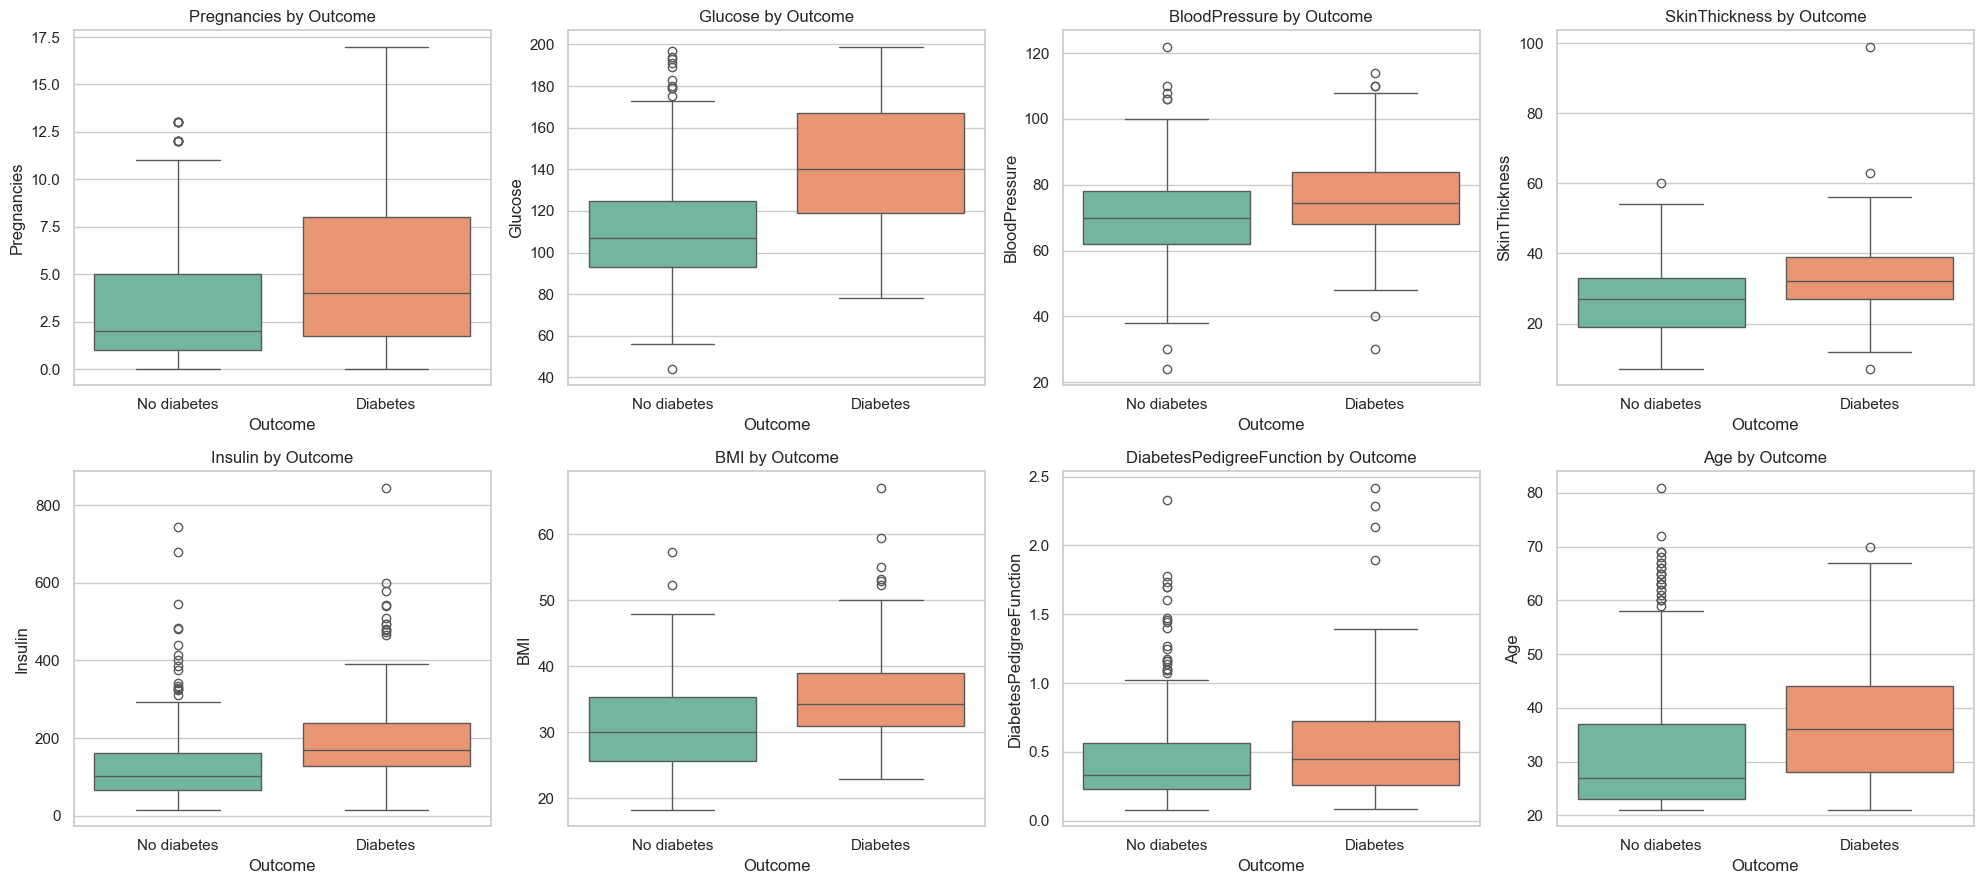

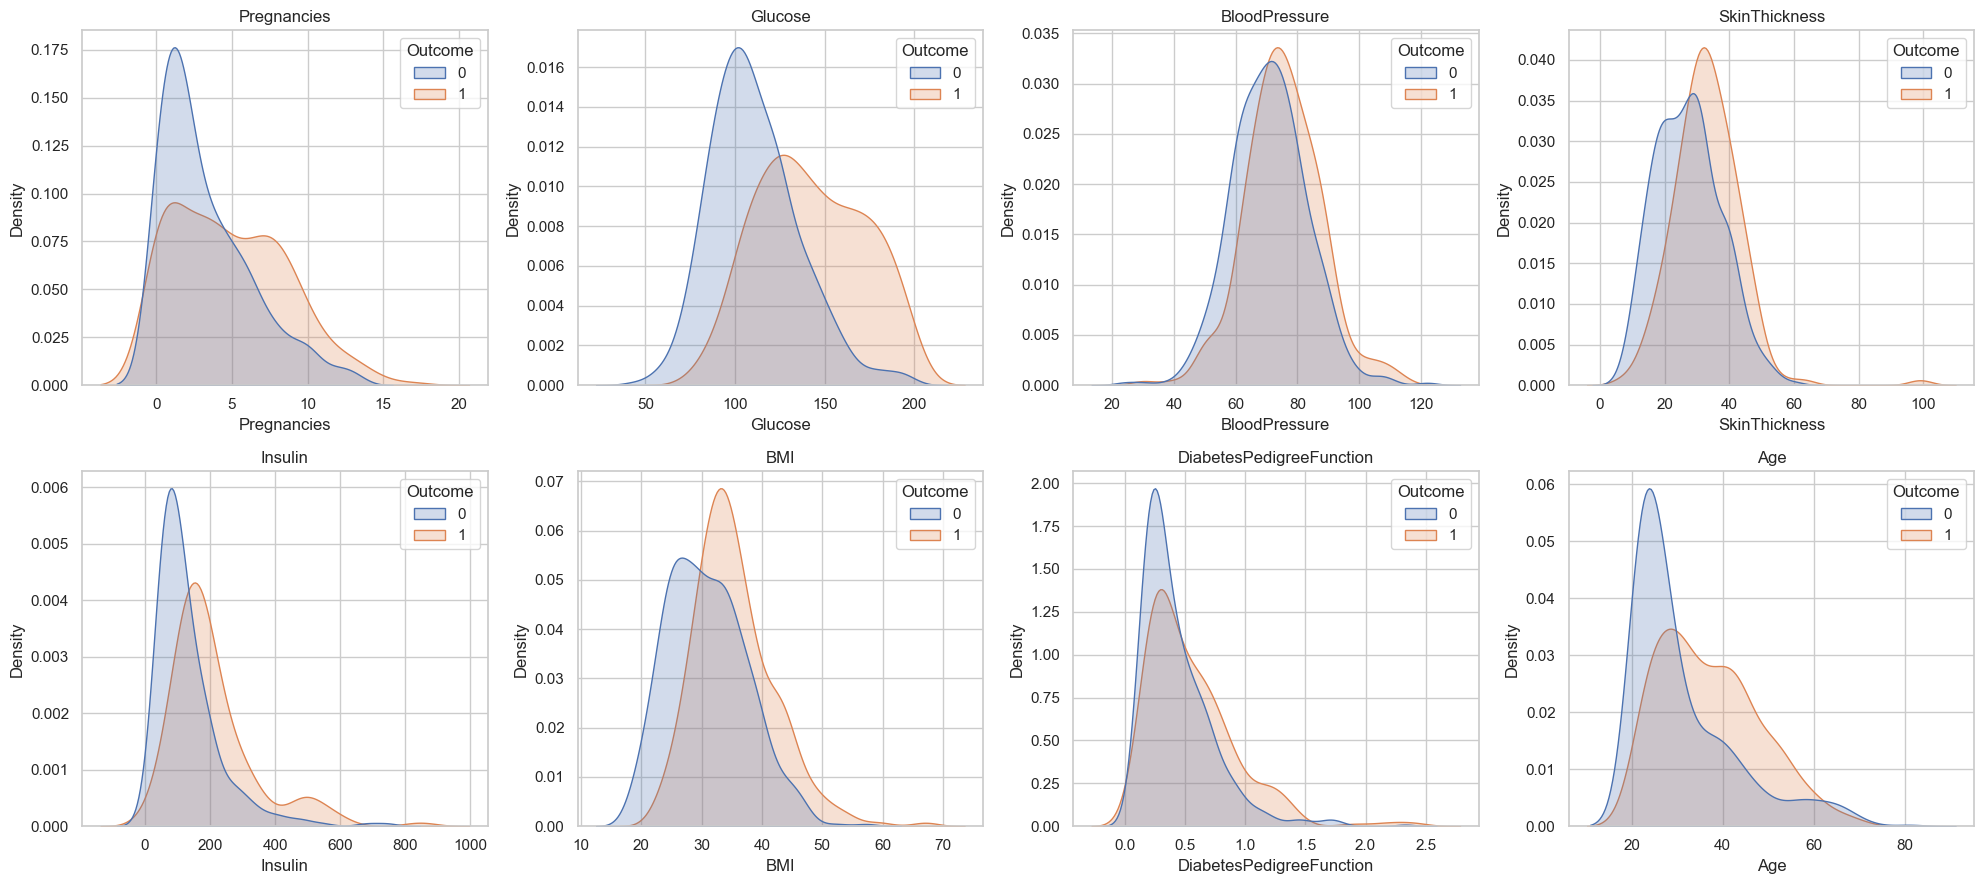

In [13]:
# Cell 1: average of each feature by outcome
summary = df.groupby("Outcome")[features].agg(["mean", "median"]).T.round(2)
display(summary)

# Cell 2: boxplots by outcome
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sns.boxplot(x="Outcome", y=col, data=df, ax=ax, palette="Set2")
    ax.set_title(f"{col} by Outcome")
    ax.set_xticklabels(["No diabetes", "Diabetes"])
plt.tight_layout()
plt.show()

# Cell 3: overlapping distributions
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sns.kdeplot(data=df, x=col, hue="Outcome", common_norm=False, fill=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Each plot compares the two groups on one feature. Blue is Outcome 0 (no diabetes) and orange is Outcome 1 (diabetes). The curves show where each group's values are concentrated. The more the orange curve is shifted away from the blue one, the better that feature separates the two groups. Heavy overlap means a weak feature.

Feature by feature
Glucose (best separator): blue peaks around 100, while orange is shifted right, peaks near 125 and spreads out to 200. Diabetic patients clearly have higher glucose, and overlap is the smallest of all the features.
Insulin: blue is a narrow peak near 80, and orange peaks higher (around 150) with a long tail past 500. Diabetic patients tend to have higher insulin.
BMI: blue peaks around 27 to 30, and orange peaks around 33 to 35. Diabetic patients are shifted toward higher BMI.
Age: blue has a sharp peak in the early 20s, while orange is flatter, with more patients between 30 and 60. Diabetes is more common in older patients.
Pregnancies: blue peaks at 1 or 2, while orange is flatter and has more patients with 5 to 10 or more pregnancies.
SkinThickness: orange is shifted slightly right (around 32 vs 25), with a lot of overlap. There is also a tiny orange bump near 100, which is the suspicious outlier from Step 7, and it belongs to a diabetic patient.
DiabetesPedigreeFunction: both curves peak at about 0.25, but orange has a thicker tail toward higher values. This is a modest difference.
BloodPressure (weakest): the curves almost sit on top of each other, with orange only slightly to the right. It barely separates the groups.

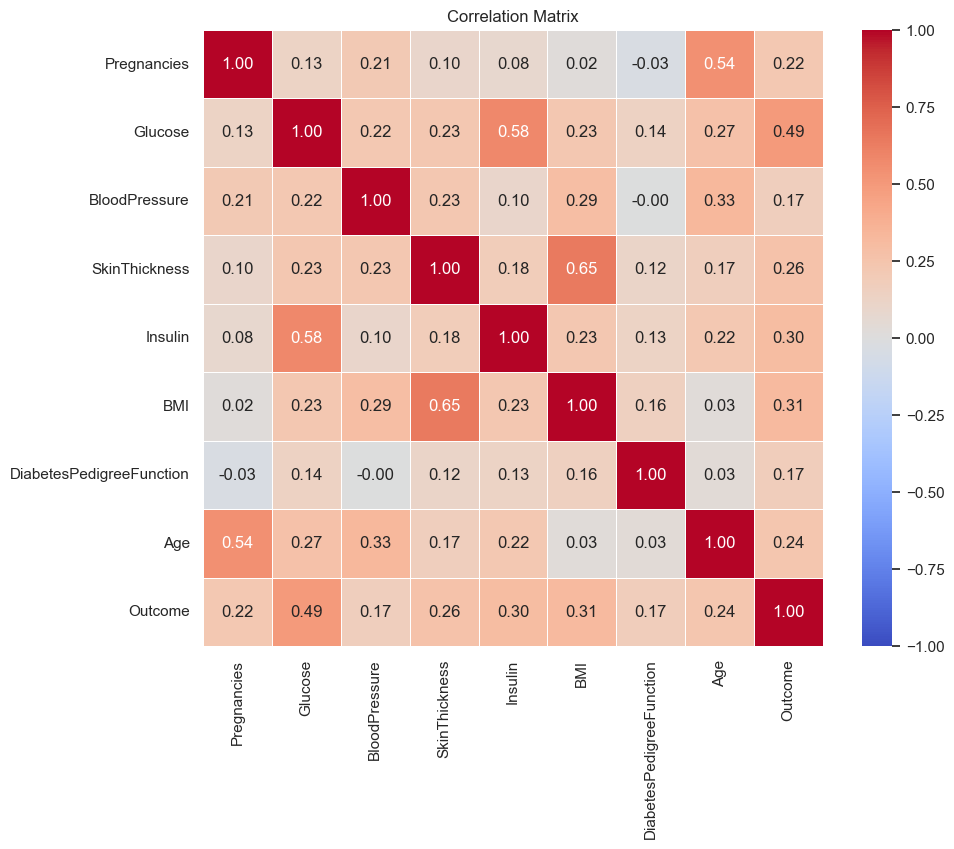

In [14]:
corr = df.corr()   # NaN values are skipped pair by pair

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [15]:
target_corr = (corr["Outcome"].drop("Outcome").sort_values(ascending=False))
display(target_corr.round(3).to_frame("correlation with Outcome"))

,correlation with Outcome
Glucose,0.495
BMI,0.314
Insulin,0.303
SkinThickness,0.259
Age,0.238
Pregnancies,0.222
DiabetesPedigreeFunction,0.174
BloodPressure,0.171


In [16]:
feat_corr = df[features].corr()
pairs = (feat_corr.where(np.triu(np.ones(feat_corr.shape), k=1).astype(bool))
         .stack().reset_index())
pairs.columns = ["feature_1", "feature_2", "correlation"]
pairs["abs_corr"] = pairs["correlation"].abs()
display(pairs.sort_values("abs_corr", ascending=False).drop(columns="abs_corr").head(6).round(3))

,feature_1,feature_2,correlation
29,SkinThickness,BMI,0.648
12,Glucose,Insulin,0.581
7,Pregnancies,Age,0.544
23,BloodPressure,Age,0.330
21,BloodPressure,BMI,0.289
15,Glucose,Age,0.267


The VIF function crashes if there are NaN (missing) values, and our data still has them in Insulin, SkinThickness and a few other columns. So for this check only, we fill the gaps in a temporary copy. Your real df is not changed.

Suppose Age gets a VIF of 1.5. That means the other 7 features explain only a little of Age, so Age brings its own information. Suppose a feature got a VIF of 12. That would mean the other features can almost rebuild it, and it would make the logistic regression coefficients unstable.

For this dataset I expect all VIFs to be below 2.

Is the median fill a problem?

It is fine for a quick check. The real imputation happens in Step 10, after the train/test split, so no information leaks from the test set.

In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_tmp = df[features].fillna(df[features].median())
X_const = add_constant(X_tmp)

vif = pd.DataFrame({
    "feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})
display(vif[vif["feature"] != "const"].sort_values("VIF", ascending=False).round(2))

,feature,VIF
8,Age,1.62
6,BMI,1.57
4,SkinThickness,1.45
1,Pregnancies,1.43
2,Glucose,1.36
3,BloodPressure,1.24
5,Insulin,1.24
7,DiabetesPedigreeFunction,1.05


define X and y, then split

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("\nOutcome share in train:\n", y_train.value_counts(normalize=True).round(3))
print("\nOutcome share in test:\n", y_test.value_counts(normalize=True).round(3))

X_train: (614, 8)  X_test: (154, 8)

Outcome share in train:
 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Outcome share in test:
 Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64


In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

# Learn the medians / means from TRAIN only, then transform
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

X_train_sc = scaler.fit_transform(X_train_imp)
X_test_sc = scaler.transform(X_test_imp)

print("Missing values left in train:", np.isnan(X_train_sc).sum())
print("Missing values left in test :", np.isnan(X_test_sc).sum())
print("\nTrain mean after scaling (about 0):", X_train_sc.mean(axis=0).round(2))
print("Train std after scaling (about 1) :", X_train_sc.std(axis=0).round(2))

Missing values left in train: 0
Missing values left in test : 0

Train mean after scaling (about 0): [-0. -0.  0. -0. -0.  0. -0. -0.]
Train std after scaling (about 1) : [1. 1. 1. 1. 1. 1. 1. 1.]


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train
log_model = LogisticRegression(random_state=42, max_iter=1000)
log_model.fit(X_train_sc, y_train)

# Predict classes (0 or 1) and probabilities
y_train_pred = log_model.predict(X_train_sc)
y_test_pred = log_model.predict(X_test_sc)
y_test_prob = log_model.predict_proba(X_test_sc)[:, 1]   # probability of diabetes

# Quick accuracy check
print("Train accuracy:", round(accuracy_score(y_train, y_train_pred), 4))
print("Test accuracy :", round(accuracy_score(y_test, y_test_pred), 4))
print("Baseline (always predict 'No diabetes'):", round((y_test == 0).mean(), 4))

# Look at 10 test patients
preview = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred,
    "Prob_diabetes": y_test_prob.round(3),
}).head(10)
display(preview)

Train accuracy: 0.7964
Test accuracy : 0.7078
Baseline (always predict 'No diabetes'): 0.6494


,Actual,Predicted,Prob_diabetes
0,0,1,0.610
1,0,0,0.118
2,0,0,0.293
3,1,0,0.251
4,0,0,0.034
5,0,0,0.168
6,1,0,0.488
7,1,1,0.924
8,0,0,0.081
9,0,1,0.839


TN = 82  FP = 18  FN = 27  TP = 27


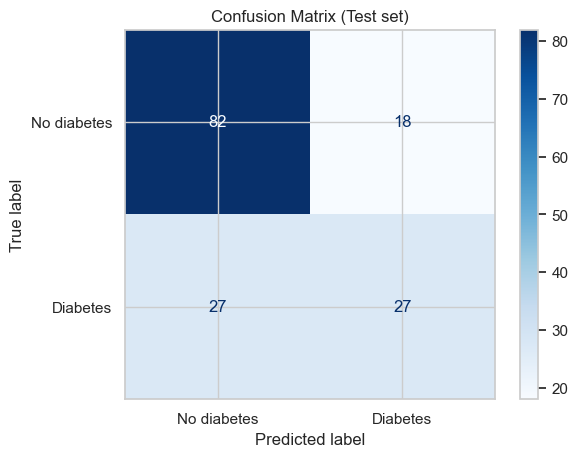

              precision    recall  f1-score   support

 No diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154

ROC-AUC: 0.813


In [21]:
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, ConfusionMatrixDisplay)

cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()
print("TN =", tn, " FP =", fp, " FN =", fn, " TP =", tp)

ConfusionMatrixDisplay(cm, display_labels=["No diabetes", "Diabetes"]).plot(cmap="Blues")
plt.title("Confusion Matrix (Test set)")
plt.show()

print(classification_report(y_test, y_test_pred, target_names=["No diabetes", "Diabetes"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_test_prob), 4))

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(pipe, X, y, cv=cv,
                        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"])

cv_table = pd.DataFrame({m: scores[f"test_{m}"] for m in
                         ["accuracy", "precision", "recall", "f1", "roc_auc"]})
display(cv_table.round(3))
print("Mean:\n", cv_table.mean().round(3))

,accuracy,precision,recall,f1,roc_auc
0,0.773,0.721,0.574,0.639,0.825
1,0.799,0.829,0.537,0.652,0.867
2,0.779,0.750,0.556,0.638,0.851
3,0.752,0.683,0.528,0.596,0.829
4,0.758,0.648,0.660,0.654,0.810


Mean:
 accuracy     0.772
precision    0.726
recall       0.571
f1           0.636
roc_auc      0.837
dtype: float64


In [24]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

final_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
])
final_pipe.fit(X_train, y_train)

# Sanity check: should match the earlier test accuracy (0.7078)
print("Test accuracy:", round(accuracy_score(y_test, final_pipe.predict(X_test)), 4))

joblib.dump(final_pipe, "diabetes_logistic_pipeline.joblib")
joblib.dump(list(X_train.columns), "diabetes_features.joblib")
print("Saved: diabetes_logistic_pipeline.joblib, diabetes_features.joblib")

Test accuracy: 0.7078
Saved: diabetes_logistic_pipeline.joblib, diabetes_features.joblib


In [25]:
import joblib
import numpy as np
import pandas as pd

pipe = joblib.load("diabetes_logistic_pipeline.joblib")
features = joblib.load("diabetes_features.joblib")

new_patient = pd.DataFrame({
    "Pregnancies": [2],
    "Glucose": [150],
    "BloodPressure": [70],
    "SkinThickness": [np.nan],     # not recorded
    "Insulin": [np.nan],           # not recorded
    "BMI": [33.6],
    "DiabetesPedigreeFunction": [0.6],
    "Age": [45],
})[features]

prob = pipe.predict_proba(new_patient)[0, 1]
print("Probability of diabetes:", round(prob, 3))
print("Prediction:", "Diabetes" if prob >= 0.5 else "No diabetes")

Probability of diabetes: 0.6
Prediction: Diabetes
